## Check python Environment

In [ ]:
import platform
import sys
import importlib.metadata

##############################################
print(f"\n###### Installed Libraries ############")
for dist in importlib.metadata.distributions():
    print(f"{dist.metadata['Name']}=={dist.version}")

# Print the Python version and other details
print(f"\n###### Python Environment Details ######")
print(f"Python Version       : {platform.python_version()}")
print(f"Python Implementation: {platform.python_implementation()}")
print(f"Executable Path      : {sys.executable}")
print(f"Platform             : {platform.system()} {platform.release()}\n\n")
##############################################

## Add simple Agent

In [ ]:
from agents import Agent, Runner
from dotenv import load_dotenv
load_dotenv(override=True)


net_expert_instruction = """
You are a senior network engineer.

Your domain of expertise is LIMITED to:
- Computer networks (LAN, WAN, routing, switching, firewalls, load balancers)
- Network protocols (TCP, UDP, IP, BGP, OSPF, HTTP, HTTPS, DNS, etc.)
- Network design, troubleshooting, and performance

HARD RULE:
- If the user asks ANYTHING that is NOT clearly about computer networking or network protocols,
  you MUST respond ONLY with exactly this sentence:
  "I don't know. I can only answer questions about computer networking."

- Do NOT try to be helpful outside your domain.
- Do NOT guess.
- Do NOT explain topics from physics, math, biology, history, programming (unless directly about networking), or any other area.
"""

network_expert_agent = Agent(
    name="Network Expert Agent",
    instructions=net_expert_instruction,
    model="gpt-5-nano"
    )

result = await Runner.run(network_expert_agent, 
                          "What is Gravity?")
print(result.final_output)

# result = Runner.run(network_expert_agent, "What is VLAN?")
# print(result)


## Simple Python Function

In [ ]:
def sleep_func(seconds: int):
    """A simple function that sleeps for a given number of seconds."""
    import time
    time.sleep(seconds)
    return f"Slept for {seconds} seconds"

print(sleep_func(2))
print(sleep_func(5))

## Coroutine

### What is Coroutine ?

```Coroutine is a special type of function which can run asynchronously when awaited```

### ⚡ Advantages of Coroutines

- 🚀 **Non-blocking execution**
- ⏳ **Efficient for I/O operations**
- 🔄 **Can pause & resume**
- 🧠 **Enables concurrency without threads**
- 🤖 **Foundation for Agentic AI workflows**

### Coroutine Example

In [ ]:
import asyncio
import datetime
# import nest_asyncio
# nest_asyncio.apply()

def now():
    return datetime.datetime.now().strftime("%H:%M:%S")

async def sleep_async_func(seconds: int):
    """A simple function that sleeps for a given number of seconds."""
    print(f"{now()} Sleeping for {seconds} seconds...")
    await asyncio.sleep(seconds)
    print(f"{now()} Slept for {seconds} seconds")
    return f"{now()} Slept for {seconds} seconds"

# await sleep_async_func(2)

await asyncio.gather(
    sleep_async_func(4),
    sleep_async_func(2),
    sleep_async_func(3)
)

### OpenAI Coroutine Example

In [ ]:
import asyncio
from openai import AsyncOpenAI
from dotenv import load_dotenv
import nest_asyncio
nest_asyncio.apply()

load_dotenv()

client = AsyncOpenAI()
def now():
    return datetime.datetime.now().strftime("%H:%M:%S")

async def llm_call(prompt: str) -> str:
    print(f"{now()} 🤖 Calling LLM with prompt: {prompt}")
    response = await client.responses.create(
        model="gpt-5-nano",
        input=prompt
    )
    print("query:", prompt, "response:", response.output_text)
    return response.output_text

async def main():
    result = await asyncio.gather(
        llm_call("Tell me a joke about cats."),
        llm_call("What is the capital of India."),
        llm_call("What's the capital of France?")
    )
    print(result)

asyncio.run(main())

### Funaction vs Coroutinne


| Aspect | Normal Function (`def`) | Coroutine (`async def`) |
|------|-------------------------|--------------------------|
| Definition keyword | `def` | `async def` |
| Execution | Runs immediately | Starts only when awaited |
| Return value | Actual result | Coroutine object |
| Blocking behavior | Blocking | Non-blocking |
| Can pause & resume | ❌ No | ✅ Yes |
| Uses `await` | ❌ Not allowed | ✅ Allowed |
| Managed by event loop | ❌ No | ✅ Yes |
| Best suited for | CPU-bound tasks | I/O-bound tasks |

## Simple Async Coroutine

In [ ]:
import asyncio
import datetime
# import nest_asyncio
# nest_asyncio.apply()

def now():
    return datetime.datetime.now().strftime("%H:%M:%S")

async def sleep_async_func(seconds: int):
    """A simple function that sleeps for a given number of seconds."""
    print(f"{now()} Sleeping for {seconds} seconds...")
    await asyncio.sleep(seconds)
    print(f"{now()} Slept for {seconds} seconds")
    return f"{now()} Slept for {seconds} seconds"

# await sleep_async_func(2)

await asyncio.gather(
    sleep_async_func(4),
    sleep_async_func(2),
    sleep_async_func(3)
)

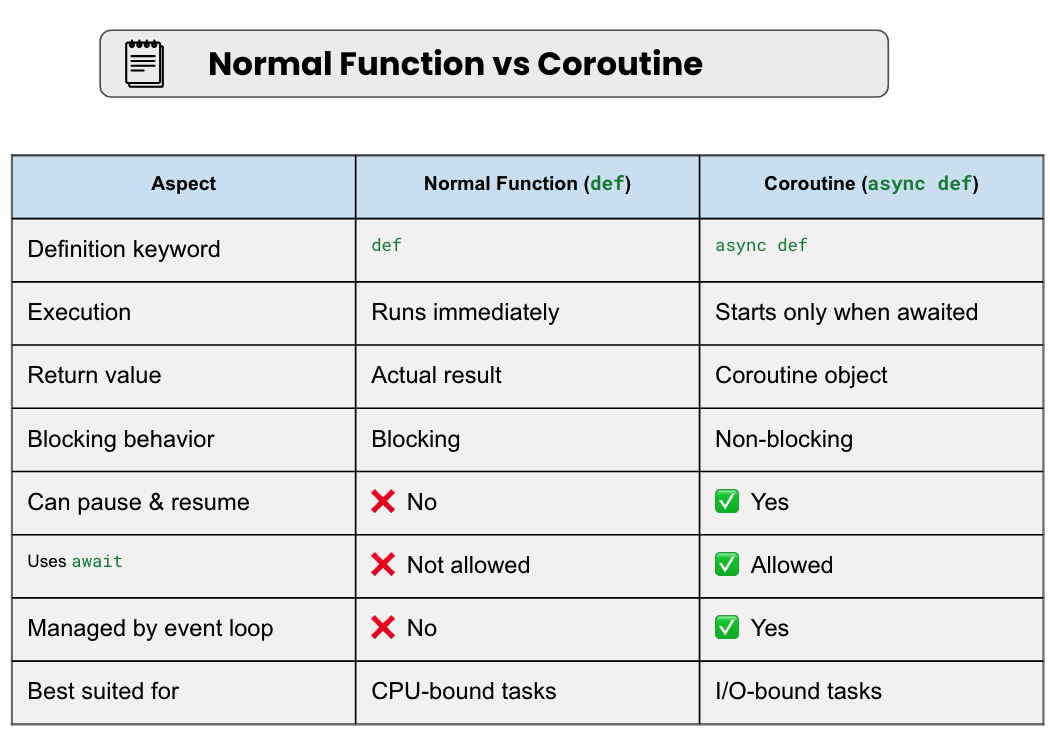

## OpenAI Example

In [ ]:
import os
import sys
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

# Check if OpenAI API key is set
api_key = os.environ.get('OPENAI_API_KEY')
if api_key:
    print(f"✅ OPENAI_API_KEY is set (length: {len(api_key)} characters)")
else:
    print("✗ OPENAI_API_KEY is not set")
    sys.exit("Error: OPENAI_API_KEY environment variable not set")
    

client = OpenAI()

def llm_call(prompt: str):
    print("🤖 Calling LLM with prompt:", prompt)
    response = client.responses.create(
        model="gpt-5-nano",
        input=prompt
    )
    return f"📝 {response.output_text}"

print(llm_call("Tell me a joke about cat"))
print(llm_call("What is the capital of France"))
    


## Implement Async in OpenAI Class

In [ ]:
import asyncio
from openai import OpenAI
from dotenv import load_dotenv
import time, datetime
load_dotenv()

client = OpenAI()

def now():
    return datetime.datetime.now().strftime("%H:%M:%S")


code_start = time.perf_counter()

async def call_llm_async(prompt: str):
    start_time = time.perf_counter()
    print(f"{now()} Calling LLM with prompt: {prompt}")
    
    response = await asyncio.to_thread(client.responses.create,
        model="gpt-5-nano",
        input=prompt
    )
    end_time = time.perf_counter()
    total_time = end_time - start_time
    print(f"{now()} {prompt} - Took: {total_time} seconds")
    print(f"{'*'*25}\n*  {prompt} - Output: {response.output_text}\n{'*'*25}")
    return {"response": response.output_text, "time_taken": total_time} 


# result = await asyncio.gather(
#     call_llm_async("Tell me a joke about cats."),
#     call_llm_async("Give me a fun fact about space."),
#     call_llm_async("What's the capital of France?"),
#     call_llm_async("What is Gravity")
# )

result = await asyncio.wait_for(
    asyncio.gather(
    call_llm_async("Tell me a joke about cats."),
    call_llm_async("Give me a fun fact about space."),
    call_llm_async("What's the capital of France?"),
    call_llm_async("What is Gravity")),
    timeout=5
)

## Handle Timeout Exception

In [ ]:
import asyncio
from openai import OpenAI
from dotenv import load_dotenv
import time, datetime
load_dotenv()

client = OpenAI()

def now():
    return datetime.datetime.now().strftime("%H:%M:%S")


code_start = time.perf_counter()

async def call_llm_async(prompt: str):
    start_time = time.perf_counter()
    print(f"{now()} Calling LLM with prompt: {prompt}")
    try:
        response = await asyncio.to_thread(client.responses.create,
            model="gpt-5-nano",
            input=prompt
        )
        end_time = time.perf_counter()
        total_time = end_time - start_time
        print(f"{now()} {prompt} - Took: {total_time} seconds")
        print(f"{'*'*25}\n*  {prompt} - Output: {response.output_text}\n{'*'*25}")
        return {"response": response.output_text, "time_taken": total_time} 

    except asyncio.CancelledError:
        # This happens when wait_for times out and cancels the task
        end_time = time.perf_counter()
        total_time = end_time - start_time
        print(f"{now()} {prompt} - CANCELLED after {total_time} seconds")
        return {"response": None, "time_taken": total_time, "status": "cancelled"}

try:
    result = await asyncio.wait_for(
        asyncio.gather(
        call_llm_async("What is Relativity theory"),
        call_llm_async("Tell me a joke about cats."),
        call_llm_async("What's the capital of India?"),
        call_llm_async("Give me a fun fact about space."),
        call_llm_async("What's the capital of France?"),
        call_llm_async("What is Gravity")),
        timeout=5
    )
except asyncio.TimeoutError as e:
    print(f"{now()} Timeout occurred! Not all LLM calls completed within 5 seconds")
    result = None
    
code_end = time.perf_counter()
total_time = code_end - code_start

print(result)
print(f"Total time taken for all LLM calls: {total_time} seconds")

## Async OpenAI Class

In [ ]:
import asyncio
from openai import AsyncOpenAI
from dotenv import load_dotenv
import nest_asyncio
nest_asyncio.apply()
load_dotenv()

client = AsyncOpenAI()

async def llm_call(prompt: str) -> str:
    response = await client.responses.create(
        model="gpt-5-nano",
        input=prompt
    )
    return response.output_text

async def main():
    result = await llm_call("Explain async and await in one sentence")
    print("🤖 Answer:", result)

# Run the event loop
asyncio.run(main())